In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, PSARIndicator
from ta.volatility import BollingerBands
from ta.utils import dropna

In [2]:
df = pd.read_csv('EURUSD_Official_Fetures_Included.csv')
print(df.shape)
df.head()

(5730, 21)


,Date,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,NaN,NaN,NaN,NaN,...,NaN,NaN,1.196501,NaN,NaN,NaN,NaN,NaN,0,1.208897
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,NaN,NaN,NaN,NaN,...,NaN,NaN,1.208897,NaN,NaN,1.196501,NaN,NaN,0,1.212298
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,NaN,NaN,NaN,NaN,...,NaN,NaN,1.204007,NaN,NaN,1.208897,NaN,NaN,1,1.208094
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,NaN,NaN,NaN,NaN,...,NaN,NaN,1.207700,NaN,NaN,1.212298,NaN,NaN,1,1.218695
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,NaN,NaN,NaN,NaN,...,NaN,NaN,1.214403,NaN,NaN,1.208094,NaN,NaN,1,1.222001


In [3]:
df = df.dropna()

In [4]:
df = df.set_index('Date')

In [5]:
print(df.shape)
df.head()

(5696, 20)


,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
Date,,,,,,,,,,,,,,,,,,,,
2004-01-15,1.265599,1.267106,1.256897,1.260097,1.260097,55.164333,0.012355,0.013950,-0.001595,1.258827,1.230817,1.286837,1.288725,39.699406,55.316378,1.265102,0.522663,0.022251,0,1.239803
2004-01-16,1.260001,1.261002,1.236400,1.239803,1.239803,43.224293,0.009374,0.013035,-0.003661,1.258892,1.231067,1.286718,1.287762,6.383659,31.992083,1.260097,0.156975,0.022103,0,1.235407
2004-01-19,1.238697,1.242406,1.234004,1.235407,1.235407,41.146781,0.006581,0.011744,-0.005163,1.258668,1.230169,1.287167,1.285708,2.518041,16.200369,1.239803,0.091895,0.022642,0,1.258907
2004-01-20,1.235102,1.260208,1.234995,1.258907,1.258907,53.902449,0.006193,0.010634,-0.004441,1.259613,1.232429,1.286797,1.282606,44.706250,17.869317,1.235407,0.487008,0.021581,0,1.265903
2004-01-21,1.258099,1.266994,1.256597,1.265903,1.265903,56.897553,0.006376,0.009782,-0.003406,1.260643,1.234155,1.287132,1.279689,57.266066,34.830119,1.258907,0.599282,0.021012,0,1.272508


In [6]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'momentum_rsi',
       'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'volatility_bbm',
       'volatility_bbl', 'volatility_bbh', 'trend_psar', 'momentum_stoch',
       'momentum_stoch_signal', 'Close_Lag1', 'bb_percent_b', 'bb_width',
       'above_psar', 'Target'],
      dtype='object')

In [7]:
X = df[['Close','momentum_rsi','trend_macd_diff','momentum_stoch','momentum_stoch_signal','Close_Lag1','bb_percent_b','bb_width','above_psar']]

In [8]:
X.head()

,Close,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar
Date,,,,,,,,,
2004-01-15,1.260097,55.164333,-0.001595,39.699406,55.316378,1.265102,0.522663,0.022251,0
2004-01-16,1.239803,43.224293,-0.003661,6.383659,31.992083,1.260097,0.156975,0.022103,0
2004-01-19,1.235407,41.146781,-0.005163,2.518041,16.200369,1.239803,0.091895,0.022642,0
2004-01-20,1.258907,53.902449,-0.004441,44.706250,17.869317,1.235407,0.487008,0.021581,0
2004-01-21,1.265903,56.897553,-0.003406,57.266066,34.830119,1.258907,0.599282,0.021012,0


In [9]:
y = df['Target']

In [10]:
y.head()

Date
2004-01-15    1.239803
2004-01-16    1.235407
2004-01-19    1.258907
2004-01-20    1.265903
2004-01-21    1.272508
Name: Target, dtype: float64

In [11]:
print(X.shape,y.shape)

(5696, 9) (5696,)


# Train Test Split

In [12]:
split_date ='2022-01-01'

In [13]:
train_mask = df.index<split_date if df.index.name=='Date' else df['Date']<split_date
test_mask =~train_mask

In [14]:
X_train,X_test = X[train_mask],X[test_mask]

In [15]:
X_train

,Close,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar
Date,,,,,,,,,
2004-01-15,1.260097,55.164333,-0.001595,39.699406,55.316378,1.265102,0.522663,0.022251,0
2004-01-16,1.239803,43.224293,-0.003661,6.383659,31.992083,1.260097,0.156975,0.022103,0
2004-01-19,1.235407,41.146781,-0.005163,2.518041,16.200369,1.239803,0.091895,0.022642,0
2004-01-20,1.258907,53.902449,-0.004441,44.706250,17.869317,1.235407,0.487008,0.021581,0
2004-01-21,1.265903,56.897553,-0.003406,57.266066,34.830119,1.258907,0.599282,0.021012,0
...,...,...,...,...,...,...,...,...,...
2021-12-27,1.132426,49.357627,0.001354,68.820675,71.710461,1.132734,0.720904,0.004570,0
2021-12-28,1.133003,50.099073,0.001373,73.392045,71.595406,1.132426,0.752662,0.004685,0
2021-12-29,1.131478,48.095309,0.001244,58.369052,66.860591,1.133003,0.618561,0.004583,1


In [16]:
X_test

,Close,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar
Date,,,,,,,,,
2022-01-03,1.137346,55.088326,0.001404,95.984331,83.462628,1.132503,0.996288,0.005751,1
2022-01-04,1.130224,46.676381,0.000992,45.766188,67.860916,1.137346,0.442210,0.005688,1
2022-01-05,1.128363,44.752262,0.000578,32.636455,58.128991,1.130224,0.292578,0.005629,1
2022-01-06,1.131350,48.425488,0.000492,53.700855,44.034499,1.128363,0.541128,0.005446,1
2022-01-07,1.129688,46.570740,0.000318,29.912664,38.749991,1.131350,0.404532,0.005432,1
...,...,...,...,...,...,...,...,...,...
2025-12-23,1.176595,66.505649,0.000747,79.358165,63.521956,1.170809,0.874867,0.010690,1
2025-12-24,1.179551,69.581354,0.000897,92.898212,73.598855,1.176595,0.944467,0.010743,1
2025-12-26,1.178536,67.296544,0.000848,87.617459,86.624612,1.179551,0.863147,0.010865,1


In [17]:
y_train,y_test=y[train_mask],y[test_mask]

In [18]:
y_train

Date
2004-01-15    1.239803
2004-01-16    1.235407
2004-01-19    1.258907
2004-01-20    1.265903
2004-01-21    1.272508
                ...   
2021-12-27    1.133003
2021-12-28    1.131478
2021-12-29    1.136015
2021-12-30    1.132503
2021-12-31    1.137346
Name: Target, Length: 4658, dtype: float64

In [19]:
y_test

Date
2022-01-03    1.130224
2022-01-04    1.128363
2022-01-05    1.131350
2022-01-06    1.129688
2022-01-07    1.135396
                ...   
2025-12-23    1.179551
2025-12-24    1.178536
2025-12-26    1.177274
2025-12-29    1.177288
2025-12-30    1.174729
Name: Target, Length: 1038, dtype: float64

In [20]:
print(f"Train size:{len(X_train)}, Test size:{len(X_test)}")

Train size:4658, Test size:1038


In [21]:
print("Train date range:", X_train.index.min(), "to", X_train.index.max())

Train date range: 2004-01-15 to 2021-12-31


In [22]:
print("Test date range:", X_test.index.min(), "to", X_test.index.max())

Test date range: 2022-01-03 to 2025-12-30


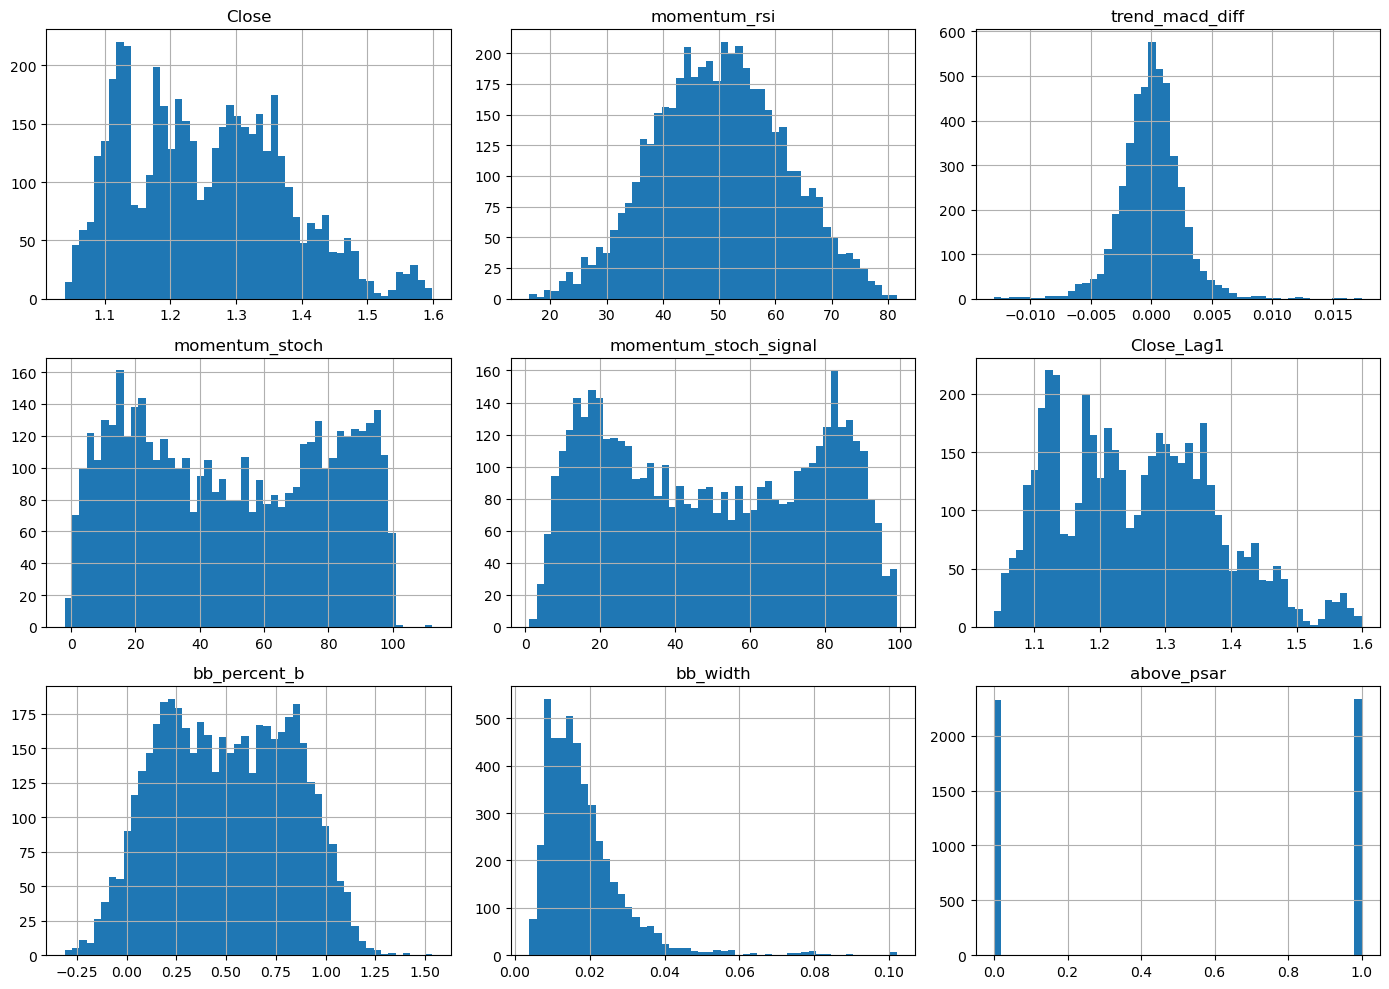

In [23]:
X_train.hist(figsize=(14,10), bins=50)
plt.tight_layout()
plt.show()

In [24]:
X_train.describe()

,Close,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar
count,4658.000000,4658.000000,4658.000000,4658.000000,4658.000000,4658.000000,4658.000000,4658.000000,4658.000000
mean,1.255570,50.063395,-0.000014,49.713935,49.711066,1.255598,0.502030,0.018406,0.501288
std,0.119428,11.524164,0.002488,29.990625,27.728168,0.119414,0.327802,0.011199,0.500052
min,1.039047,16.281011,-0.013004,-2.001748,1.086809,1.039047,-0.311739,0.003835,0.000000
25%,1.155505,41.860979,-0.001426,22.050772,23.877710,1.155535,0.228647,0.011191,0.000000
50%,1.247373,50.110545,0.000044,48.187008,48.483476,1.247489,0.498635,0.015848,1.000000
75%,1.340177,58.069916,0.001372,77.239948,76.187591,1.340177,0.776540,0.022200,1.000000
max,1.598798,81.588468,0.017371,112.299322,99.318648,1.598798,1.537433,0.102124,1.000000


<AxesSubplot:title={'center':'Targt (Test)'}, xlabel='Date'>

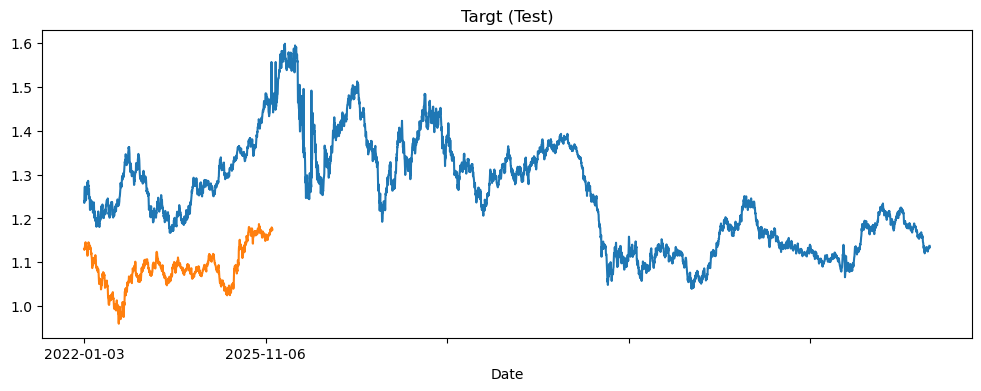

In [25]:
y_train.plot(figsize=(12,4),title="Target  (Train)")
y_test.plot(figsize=(12,4), title="Targt (Test)")

In [26]:
print("Train target stats:\n",y_train.describe())

Train target stats:
 count    4658.000000
mean        1.255543
std         0.119440
min         1.039047
25%         1.155405
50%         1.247326
75%         1.340177
max         1.598798
Name: Target, dtype: float64


In [27]:
print("Test target stats:\n",y_test.describe())

Test target stats:
 count    1038.000000
mean        1.086785
std         0.046073
min         0.959619
25%         1.059847
50%         1.084575
75%         1.109075
max         1.187141
Name: Target, dtype: float64


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

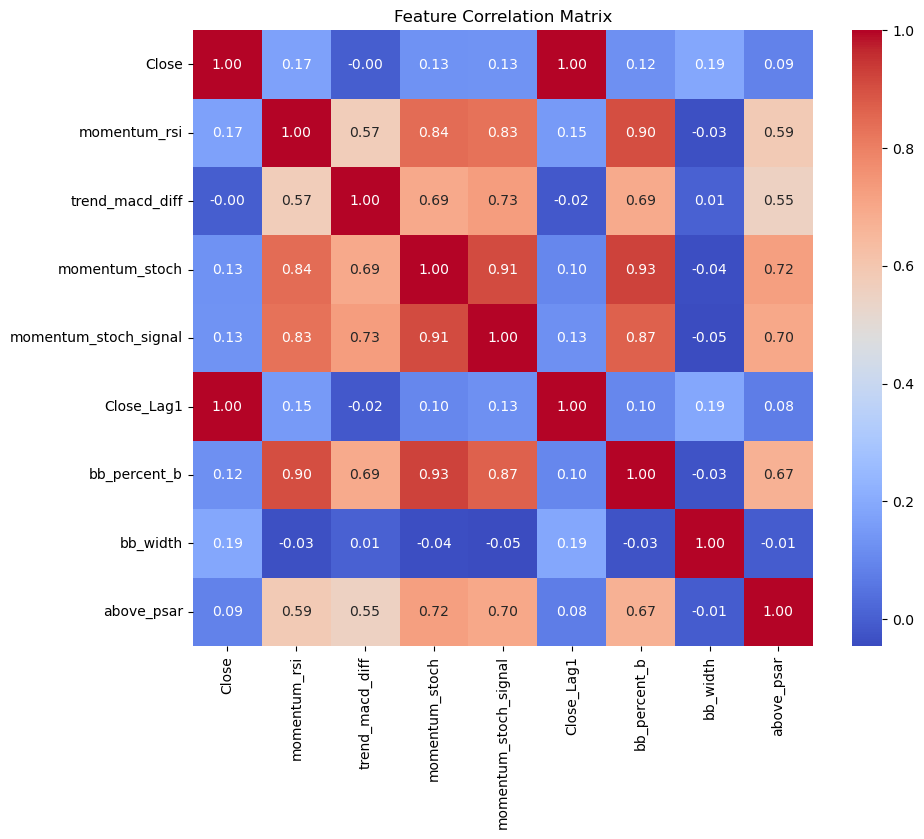

In [29]:
corr_matrix=X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 

In [31]:
vif_data = pd.DataFrame()
vif_data['feature']=X.columns
vif_data['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF',ascending=False))

                 feature           VIF
0                  Close  32754.670267
5             Close_Lag1  32608.811697
1           momentum_rsi     93.710713
3         momentum_stoch     51.464347
4  momentum_stoch_signal     47.253794
6           bb_percent_b     35.791796
8             above_psar      4.423815
7               bb_width      4.027445
2        trend_macd_diff      2.434358


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:
baseline_pred = X_test['Close']

In [34]:
baseline_mae = mean_absolute_error(y_test,baseline_pred)

In [35]:
print(f"Baseline MAE: {baseline_mae:.5f}")

Baseline MAE: 0.00400


In [36]:
baseline_rmse = np.sqrt(mean_squared_error(y_test,baseline_pred))

In [37]:
print(f"Baseline rsme: {baseline_rmse:.5f}")

Baseline rsme: 0.00534


In [38]:
print(y_test.index.equals(baseline_pred.index))

True


In [39]:
y_test.head()

Date
2022-01-03    1.130224
2022-01-04    1.128363
2022-01-05    1.131350
2022-01-06    1.129688
2022-01-07    1.135396
Name: Target, dtype: float64

In [40]:
baseline_pred.head()

Date
2022-01-03    1.137346
2022-01-04    1.130224
2022-01-05    1.128363
2022-01-06    1.131350
2022-01-07    1.129688
Name: Close, dtype: float64

In [41]:
check = pd.DataFrame({'y_test': y_test.squeeze(),
                     'baseline_pred':baseline_pred.squeeze()})

In [42]:
check.head()

,y_test,baseline_pred
Date,,
2022-01-03,1.130224,1.137346
2022-01-04,1.128363,1.130224
2022-01-05,1.131350,1.128363
2022-01-06,1.129688,1.131350
2022-01-07,1.135396,1.129688


In [43]:
manual_mpe = np.mean(np.abs(check['y_test'] - check['baseline_pred'])/check['y_test'])*100

In [44]:
manual_mpe

0.3706722634185774

In [45]:
print(baseline_pred.head())

Date
2022-01-03    1.137346
2022-01-04    1.130224
2022-01-05    1.128363
2022-01-06    1.131350
2022-01-07    1.129688
Name: Close, dtype: float64


In [46]:
print(baseline_pred.equals(X_test['Close']))

True


# Decision Tree 

In [47]:
from sklearn.tree import DecisionTreeRegressor

In [48]:
dt_model = DecisionTreeRegressor(max_depth=5,random_state=42)
dt_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [50]:
dt_pred = dt_model.predict(X_test)

In [51]:
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test,dt_pred))
dt_mape = np.mean(np.abs(y_test - dt_pred)/y_test)*100

In [52]:
print(f"Decision Tree MAE: {dt_mae:.5f}")
print(f"Decision Tree RMSE: {dt_rmse:.5f}")
print(f"Decision Tree MAPE: {dt_mape:.2f}%")

Decision Tree MAE: 0.00982
Decision Tree RMSE: 0.01716
Decision Tree MAPE: 0.94%


In [53]:
y_train.shape,y_test.shape

((4658,), (1038,))

In [54]:
dt_train_pred = dt_model.predict(X_train)

In [55]:
dt_train_mae = mean_absolute_error(y_train,dt_train_pred)
dt_train_rmse = np.sqrt(mean_squared_error(y_train,dt_train_pred))
dt_train_mape = np.mean(np.abs(y_train - dt_train_pred)/y_train)*100

In [56]:
print(f"Decison Tree Train MAE:{dt_train_mae:.5f}")
print(f"Decision Tree Train RMSE:{dt_train_rmse:.5f}")
print(f"Decision Tree Train MAPE:{dt_train_mape:.2f}%")

Decison Tree Train MAE:0.00674
Decision Tree Train RMSE:0.00995
Decision Tree Train MAPE:0.53%


# Random Forest

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [58]:
rf_model = RandomForestRegressor(n_estimators = 200, max_depth = 5, random_state = 42, n_jobs = -1)

In [59]:
rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, n_jobs=-1, random_state=42)

In [60]:
rf_pred = rf_model.predict(X_test)

In [61]:
rf_train_pred  = rf_model.predict(X_train)

In [62]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))
rf_mape = np.mean(np.abs(y_test - rf_pred)/y_test)*100

In [63]:
rf_train_mae = mean_absolute_error(y_train,rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train,rf_train_pred))
rf_train_mape = np.mean(np.abs(y_train - rf_train_pred)/y_train)*100

In [64]:
print(f"Random Forest Train MAE:{rf_train_mae:.5f}    Test MAE:{rf_mae:.5f}")
print(f"Random Forest Train RMSE:{rf_train_rmse:.5f}    Test RMSE:{rf_rmse:.5f}")
print(f"Random Forest Train MAPE:{rf_train_mape:.2f}%    Test MAPE:{rf_mape:.2f}%")

Random Forest Train MAE:0.00573    Test MAE:0.00966
Random Forest Train RMSE:0.00897    Test RMSE:0.01861
Random Forest Train MAPE:0.45%    Test MAPE:0.93%


<AxesSubplot:title={'center':'Random Forest Feature Importance'}>

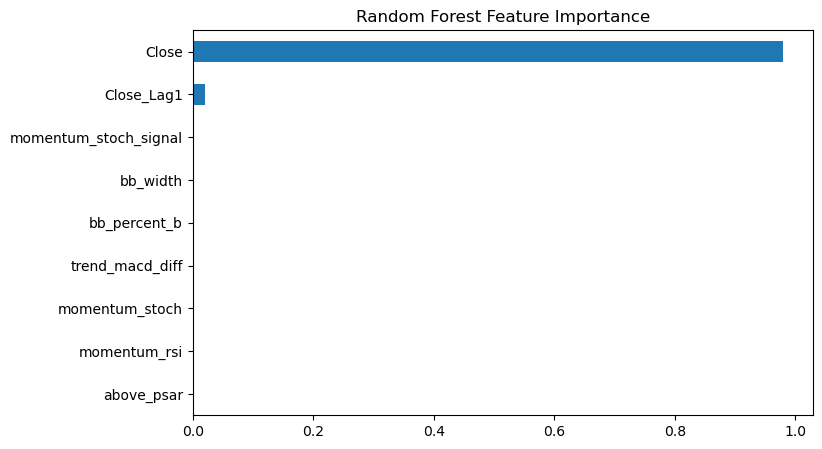

In [65]:
importance = pd.Series(rf_model.feature_importances_,index=X_train.columns)
importance.sort_values(ascending=True).plot(kind='barh',figsize=(8,5), title="Random Forest Feature Importance")

In [69]:
rf_model_v2 = RandomForestRegressor(n_estimators = 200, max_depth = 10, min_samples_leaf = 5, random_state = 42, n_jobs = -1)

In [70]:
rf_model_v2.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [71]:
rf_pred_v2 = rf_model_v2.predict(X_test)

In [72]:
rf_train_pred_v2 = rf_model_v2.predict(X_train)

In [73]:
rf_mae_v2 = mean_absolute_error(y_test,rf_pred_v2)
rf_rsme_v2 = np.sqrt(mean_squared_error(y_test,rf_pred_v2))
rf_mape_v2 = np.mean(np.abs(y_test - rf_pred_v2)/y_test)*100

In [74]:
rf_mae_train_v2 = mean_absolute_error(y_train,rf_train_pred_v2)
rf_rsme_train_v2 = np.sqrt(mean_squared_error(y_train,rf_train_pred_v2))
rf_mape_train_v2 = np.mean(np.abs(y_train - rf_train_pred_v2)/y_train)*100

In [75]:
print(f"RF train MAE:{rf_mae_train_v2:.5f}     RF test MAE:{rf_mae_v2:.5f}")
print(f"RF train RSME:{rf_rsme_train_v2:.5f}   RF test RSME:{rf_rsme_v2:.5f}")
print(f"RF train MAPE:{rf_mape_train_v2:.2f}%   RF test MAPE:{rf_mape_v2:.2f}%")

RF train MAE:0.00423     RF test MAE:0.00818
RF train RSME:0.00714   RF test RSME:0.01570
RF train MAPE:0.33%   RF test MAPE:0.79%


# Hyperparamater Tuning

In [ ]:
GridsSearchCV TimeSeriesSplit

In [156]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [166]:
tscv = TimeSeriesSplit(n_splits = 5)

param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5,8,10,15,None],
    'min_samples_leaf' : [1,3,5,10],
    'max_features' : ['sqrt',0.8,1.0]
}

rf_search = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_grid,
    n_iter = 20,
    scoring = 'neg_mean_absolute_error',
    cv = tscv,
    random_state = 42,
    n_jobs = -1,
    verbose = 1
)

In [167]:
rf_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 10, 15, None],
                                        'max_features': ['sqrt', 0.8, 1.0],
                                        'min_samples_leaf': [1, 3, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [168]:
print("Best Params:", rf_search.best_params_)

Best Params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 8}


In [170]:
print("Best CV MAE:", -rf_search.best_score_)

Best CV MAE: 0.023858542881715936


In [173]:
best_rf = rf_search.best_estimator_

rf_pred_tuned = best_rf.predict(X_test)
rf_train_pred_tuned = best_rf.predict(X_train)

In [174]:
rf_mae_tuned = mean_absolute_error(y_test,rf_pred_tuned)
rf_rmse_tuned = np.sqrt(mean_squared_error(y_test,rf_pred_tuned))
rf_mape_tuned = np.mean(np.abs(y_test - rf_pred_tuned)/y_test)*100

In [176]:
print(f"Tuned RF test mae:{rf_mae_tuned:.5f}")
print(f"Tuned RF test rsme:{rf_rmse_tuned:.5f}")
print(f"Tuned RF test mape:{rf_mape_tuned:.2f}%")

Tuned RF test mae:0.00816
Tuned RF test rsme:0.01568
Tuned RF test mape:0.79%


# XGBoost

In [177]:
from xgboost import XGBRegressor

In [179]:
xgb_model = XGBRegressor(
    n_estimators = 200,
    max_depth = 5,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1
    
)

xgb_model.fit(X_train,y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_train_pred = xgb_model.predict(X_train)

In [186]:
xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_rsme = np.sqrt(mean_squared_error(y_test,xgb_pred))
xgb_mape = np.mean(np.abs(y_test - xgb_pred)/y_test)*100

In [187]:
xgb_train_mae = mean_absolute_error(y_train,xgb_train_pred)
xgb_train_rsme = np.sqrt(mean_squared_error(y_train,xgb_train_pred))
xgb_train_mape = np.mean(np.abs(y_train - xgb_train_pred)/y_train)*100

In [190]:
print(f"XGB trian MAE:{xgb_train_mae:.5f}    XGB test MAE:{xgb_mae:.5f}")
print(f"XGB train RSME:{xgb_train_rsme:.5f}  XGB test RSME:{xgb_rsme:.5f}")
print(f"XGB train MAPE:{xgb_train_mape:.2f}%  XGB test MAPE:{xgb_mape:.2f}%")

XGB trian MAE:0.00461    XGB test MAE:0.00814
XGB train RSME:0.00639  XGB test RSME:0.01592
XGB train MAPE:0.36%  XGB test MAPE:0.79%


# Feature Importance

<AxesSubplot:title={'center':'XGBoost Feature Importance'}>

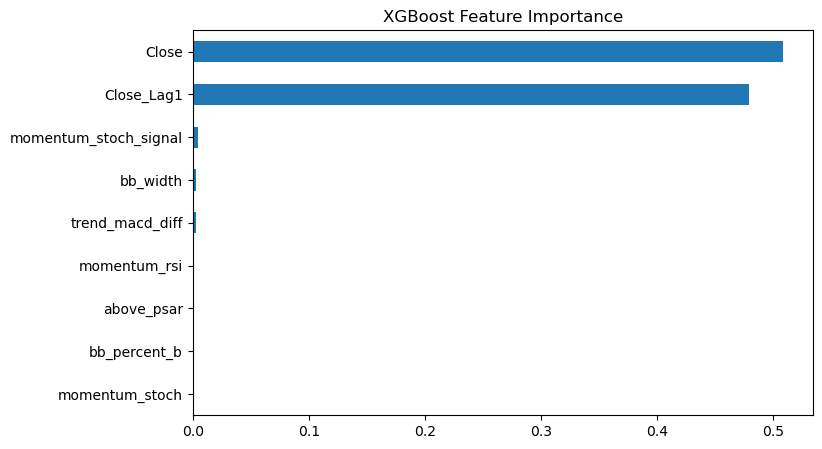

In [192]:
importance = pd.Series(xgb_model.feature_importances_,index=X_train.columns)
importance.sort_values(ascending=True).plot(kind='barh',figsize=(8,5), title="XGBoost Feature Importance")